In [1]:
import torch

def Render(x):
    return x**2 + 2*x

device = 'cuda'
target_x = torch.tensor(3.0, device = device)
target = Render(target_x)

init_x = torch.tensor(1.0, device = device)
init = Render(init_x)

x = init_x.clone().detach().requires_grad_(True)

optimizer = torch.optim.Adam([x], lr=0.05)

step_size = 100

for step in range(step_size):
    optimizer.zero_grad()

    current = Render(x)
    loss = torch.mean((current - target) ** 2)

    loss.backward()

    optimizer.step()

    if step % 10 == 0:
        print(f"step={step:3d}, x={x.item():.6f}, loss={loss.item():.6f}")

print("\n최종 결과")
print("x =", x.item())
print("target =", target_x.item())

step=  0, x=1.050000, loss=144.000000
step= 10, x=1.550623, loss=95.008018
step= 20, x=2.045771, loss=49.242481
step= 30, x=2.505790, loss=16.069204
step= 40, x=2.870730, loss=1.560605
step= 50, x=3.072446, loss=0.238523
step= 60, x=3.105360, loss=0.763249
step= 70, x=3.050175, loss=0.209291
step= 80, x=2.996001, loss=0.000001
step= 90, x=2.978870, loss=0.028048

최종 결과
x = 2.9866790771484375
target = 3.0


In [2]:
test = torch.tensor([[0,1,2], [3,4,5], [6,7,8]], device=device)
print(test)
test0 = torch.flip(test, dims=[0])
test1 = torch.flip(test, dims=[1])
print(test0)
print(test1)

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]], device='cuda:0')
tensor([[6, 7, 8],
        [3, 4, 5],
        [0, 1, 2]], device='cuda:0')
tensor([[2, 1, 0],
        [5, 4, 3],
        [8, 7, 6]], device='cuda:0')


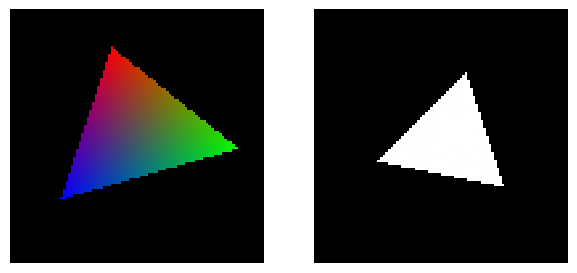

In [3]:
import matplotlib.pyplot as plt
import numpy

def edge(v0, v1, P):
    e0 = v1 - v0
    e1 = P - v0

    return (v1[..., 0] - v0[...,0]) * (P[..., 1] - v0[...,1]) - (v1[..., 1] - v0[...,1]) * (P[..., 0] - v0[...,0])

def Render(vertices, colors, P):
    v0, v1, v2 = vertices[0], vertices[1],vertices[2]

    area = edge(v0, v1, v2)
    s = 1.0 if area >=0.0 else -1.0
    area = torch.where(torch.abs(area) < 1e-12, s * torch.tensor(1e-12,device=area.device), area)
    w2 = edge(v0, v1, P) / area
    w0 = edge(v1, v2, P) / area
    w1 = edge(v2, v0, P) / area
    inside = (w0 >= 0) & (w1>= 0.0) & (w2>=0.0)

    img = torch.zeros((H, W, 3), device=device, dtype=torch.float32)
    rgbs = (w0[...,None] * colors[0] + w1[...,None] * colors[1] + w2[...,None] * colors[2])
    rgbs = torch.clamp(rgbs, 0.0 , 1.0)
    img[inside] = rgbs[inside]

    return img


W = 96
H = 96

device = 'cuda'

x = (2.0 * (torch.arange(W, device = device) + 0.5)) / W - 1.0
y = (2.0 * (torch.arange(H, device = device) + 0.5)) / H - 1.0
Y, X = torch.meshgrid([y,x], indexing='ij')
Y = torch.flip(Y, dims=[0])
P = torch.stack([X, Y], dim=-1)

vertices = torch.tensor([[-0.2, 0.7], 
                         [0.8, -0.1],
                         [-0.6,-0.5]],
                         dtype=torch.float32, device=device)
colors = torch.tensor([[1.0,0.0,0.0],
                       [0.0,1.0,0.0],
                       [0.0,0.0,1.0]],
                        dtype=torch.float32, device=device)

init_vertices = torch.tensor([[0.2, 0.5], 
                         [0.5, -0.4],
                         [-0.5,-0.2]],
                         dtype=torch.float32, device=device)
init_colors = torch.tensor([[1.0,1.0,1.0],
                       [1.0,1.0,1.0],
                       [1.0,1.0,1.0]],
                        dtype=torch.float32, device=device)

target = Render(vertices, colors, P)
init_img = Render(init_vertices, init_colors, P)

fig, axes = plt.subplots(1,2,figsize=(7.2,3.6))
axes[0].axis('off')
axes[1].axis('off')
axes[0].imshow(target.cpu().numpy(), interpolation="nearest")
axes[1].imshow(init_img.cpu().numpy(), interpolation="nearest")


plt.show()

In [4]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import Video

def save_training_video(frames, filename, fps=30, title="Training Progress"):
    """Save list of image frames as MP4 video."""
    if len(frames) == 0:
        print(f"No frames to save for {filename}")
        return
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(title)
    ax.axis('off')
    
    # Initialize with first frame
    im_display = ax.imshow(frames[0], vmin=0.0, vmax=1.0, interpolation="nearest")
    text = ax.text(0.5, -0.05, f"Iteration: 0", transform=ax.transAxes, 
                   ha='center', fontsize=12)
    
    def update(frame_idx):
        im_display.set_array(frames[frame_idx])
        text.set_text(f"Iteration: {frame_idx}")
        return [im_display, text]
    
    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000/fps, blit=True)
    
    # Save as MP4
    writer = FFMpegWriter(fps=fps, bitrate=1800)
    anim.save(filename, writer=writer)
    plt.close(fig)
    print(f"Video saved to {filename}")

In [5]:
frames = []


hard_edge_train = 200

v = init_vertices.clone().requires_grad_(True)
c = init_colors.clone().requires_grad_(True)
optimizer = torch.optim.Adam([v, c], lr=0.01)

for i in range(hard_edge_train):

    optimizer.zero_grad()
    img = Render(v,c,P)
    loss = torch.mean((target -img ) ** 2)

    loss.backward()

    optimizer.step()

    frames.append(img.cpu().detach().numpy())

save_training_video(frames, 'test.mp4')

Video saved to test.mp4


In [ ]:
def Render_Soft_Edge(P, vertices,colors, k):
    v0, v1, v2 = vertices[0], vertices[1],vertices[2]

    area = edge(v0, v1, v2)
    s = 1.0 if area >=0.0 else -1.0
    area = torch.where(torch.abs(area) < 1e-12, s * torch.tensor(1e-12,device=area.device), area)
    w2 = edge(v0, v1, P) / area
    w0 = edge(v1, v2, P) / area
    w1 = edge(v2, v0, P) / area
    inside = (w0 >= 0) & (w1>= 0.0) & (w2>=0.0)

    img = torch.zeros((H, W, 3), device=device, dtype=torch.float32)
    rgbs = (w0[...,None] * colors[0] + w1[...,None] * colors[1] + w2[...,None] * colors[2])
    rgbs = torch.clamp(rgbs, 0.0 , 1.0)
    img[inside] = rgbs[inside]

    return img